In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import statistics
import numpy as np
pathToFolder = ""
plt.rcParams.update({'font.size': 10})

results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

all_throughput_results = []
all_median_fairness_results = []
all_max_fairness_results = []
all_time_results = []
all_first2_results = []

util_with_udp_array = []

labels = []

fifo_or_cebinae = ""

In [2]:
def plot():
    # throughput calculation
    time_1 = []
    time_2 = []
    time_3 = []
    time_4 = []
    throughput_array_1 = []
    throughput_array_2 = []
    throughput_array_3 = []
    throughput_array_4  = []
    throughput_array_udp = []
    packet_drop_1 = []
    packet_drop_2 = []
    packet_drop_3 = []
    packet_drop_4 = []
            
    # if any file is does not have entries that go until [duration--30s], print error and change experiments    
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-0-0-1.out', 'r') as rf:
        last_time_of_file = float(rf.readlines()[-1][0:4])
        if (last_time_of_file < 29):
            print("error in file 0-0-1.out")
            print(last_time_of_file)
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-0-0-2.out', 'r') as rf:
        last_line_of_file = rf.readlines()[-1]
        last_time_of_file = float(last_line_of_file.split(" IP", 1)[0])
        if (last_time_of_file < 29):
            print("error in 0-0-2.out")
            print(last_time_of_file)

    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-0-0-3.out', 'r') as rf:
        last_time_of_file = float(rf.readlines()[-1][0:4])
        last_time_of_file = float(last_line_of_file.split(" IP", 1)[0])
        if (last_time_of_file < 29):
            print("error in 0-0-3.out")
            print(last_time_of_file)

    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-0-0-4.out', 'r') as rf:
        last_time_of_file = float(rf.readlines()[-1][0:4])
        last_time_of_file = float(last_line_of_file.split(" IP", 1)[0])
        if (last_time_of_file < 29):
            print("error in 0-0-4.out")
            print(last_time_of_file)

    ################################################ throughput ###########################################################
    # # # # # # # # # # # # # # # # # # # # # # # #  four flows # # # # # # # # # # # # # # # # # # # # # # # # # # #

    time_total_throughput = []
    total_throughput_array = []

    prev_recorded_time: float = 0
    total_time: float = 0
    total_size: float = 0
    time_index = 0.1
    total_throughput_array = []

    # total throughput

    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-full-throughput-sorted.out', 'r') as rf:
        for line in rf:
            # current time
            total_time = float(line.split(" IP", 1)[0])

            # current size
            currentLineToSplit = line.split("length ", 1)[1]
            if (line.split("length ", 1)[1].__contains__(":")):
                size = int(currentLineToSplit.split(": HTTP")[0]) + 40
            else:
                size = int(line.split("length ", 1)[1]) + 28
            size = size * 8
            total_size += size


            if (total_time >= time_index):

                # add 100 ms interval to time array
                time_total_throughput.append(round(time_index, 2))

                # add throughput to throughput array
                throughput = (total_size - size) / 0.1 # throughput (size / time)


                total_throughput_array.append(throughput / 1000000) # convert bps to Mbps

                time_index += 0.1
                total_size = size
                prev_recorded_time = last_time
            last_time = total_time


    prev_time = 0
    total_time = 0
    total_size = 0
    prev_recorded_time = 0
    last_time = 0
    time_index = 0.1 # not used right now

    # throughput 1
    prev_seq_number: float = 0
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-0-0-1.out', 'r') as rf:
        for line in rf:
            # current time
            total_time = float(line.split(" IP", 1)[0])
            
            if (line.__contains__("seq") and line.__contains__(":") and not line.__contains__("seq 0")):
                temp_seq = line.split("seq ", 1)[1]
                current_seq_number = float(temp_seq.split(":", 1)[0])
#                 print("current:",(current_seq_number),"previous:",prev_seq_number, type(current_seq_number), type(prev_seq_number))
                if ((current_seq_number) < (prev_seq_number)):
                    packet_drop_1.append(total_time) 
                prev_seq_number = current_seq_number

            # current size
            currentLineToSplit = line.split("length ", 1)[1]
            if (line.split("length ", 1)[1].__contains__(":")):
                size = int(currentLineToSplit.split(": HTTP")[0]) + 40
            else:
                size = int(line.split("length ", 1)[1]) + 28
            size = size * 8
            total_size += size


            if (total_time >= time_index):

                # add 100 ms interval to time array
                time_1.append(round(time_index, 2))

                # add throughput to throughput array
                throughput = (total_size - size) / 0.1 # throughput (size / time)


                throughput_array_1.append(throughput / 1000000) # convert bps to Mbps

                time_index += 0.1
                total_size = size
                prev_recorded_time = last_time
            last_time = total_time

    # throughput 2

    prev_time = 0
    total_time = 0
    total_size = 0
    prev_recorded_time = 0
    last_time = 0
    time_index = 0.1 # not used right now
    first_index_in_array_from_data = 0
    prev_seq_number: float = 0
    # used to calculate where time_index should be
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-0-0-2.out', 'r') as rf:
        for line in rf:
            time_index = float(line[0:3]) + 0.1 # current time + 0.1 to make future time_index
            first_index_in_array_from_data = time_index
            # bookmark first_index_in_array_from_data_2 for throughput calculations later (measuring throughput of first second)
            first_index_in_array_from_data_2 = first_index_in_array_from_data
            break
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-0-0-2.out', 'r') as rf:
        for line in rf:
            # current time
            total_time = float(line.split(" IP", 1)[0])
            
            if (line.__contains__("seq") and line.__contains__(":") and not line.__contains__("seq 0")):
                temp_seq = line.split("seq ", 1)[1]
                current_seq_number = float(temp_seq.split(":", 1)[0])
#                 print("current:",(current_seq_number),"previous:",prev_seq_number, type(current_seq_number), type(prev_seq_number))
                if ((current_seq_number) < (prev_seq_number)):
                    packet_drop_2.append(total_time) 
                prev_seq_number = current_seq_number

            # current size
            currentLineToSplit = line.split("length ", 1)[1]
            if (line.split("length ", 1)[1].__contains__(":")):
                size = int(currentLineToSplit.split(": HTTP")[0]) + 40
            else:
                size = int(line.split("length ", 1)[1]) + 28
            size = size * 8
            total_size += size

            if (total_time >= time_index):

                # add 100 ms interval to time array
                time_2.append(round(time_index, 2))

                # add throughput to throughput array
                throughput = (total_size - size) / 0.1 # throughput (size / time)

                throughput_array_2.append(throughput / 1000000) # convert bps to Mbps

                time_index += 0.1
                total_size = size
                prev_recorded_time = last_time
            last_time = total_time

    time_index = 0.1
    index = 0
    inserted_all_new_indices = False
    # compare time_index (0.1) to first time in file 0-0-2 (time when first packet is received)
    while (time_index < first_index_in_array_from_data):
        # insert time_index in time array to fill time (to match length of time_1)--match flow start time
        time_2.insert(index, round(time_index, 2))
        throughput_array_2.insert(index, 0)
        index += 1
        time_index += 0.1
        # when time_index has reached the first time in the file (when flow starts), stop inserting new values
        if (time_index == first_index_in_array_from_data):
            inserted_all_new_indices = True

    # if flow stops just before 29.9 (between 19 and 29.9--see above for error for flow stopping before 19s)
    # append time_index and throughput = 0 until array lengths are the same
    last_time_index = time_2[-1]
    while (last_time_index < last_time_of_file):
        last_time_index += 0.1
        time_2.append(round(last_time_index, 2))
        throughput_array_2.append(0)


    # throughput 3

    prev_time = 0
    total_time = 0
    total_size = 0
    prev_recorded_time = 0
    last_time = 0
    time_index = 0.1 # not used right now
    first_index_in_array_from_data = 0
    prev_seq_number: float = 0
    # used to calculate where time_index should be
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-0-0-3.out', 'r') as rf:
        for line in rf:
            time_index = float(line[0:3]) + 0.1 # current time + 0.1 to make future time_index
            first_index_in_array_from_data = time_index
            break
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-0-0-3.out', 'r') as rf:
        for line in rf:
            # current time
            total_time = float(line.split(" IP", 1)[0])
            
            if (line.__contains__("seq") and line.__contains__(":") and not line.__contains__("seq 0")):
                temp_seq = line.split("seq ", 1)[1]
                current_seq_number = float(temp_seq.split(":", 1)[0])
#                 print("current:",(current_seq_number),"previous:",prev_seq_number, type(current_seq_number), type(prev_seq_number))
                if ((current_seq_number) < (prev_seq_number)):
                    packet_drop_3.append(total_time) 
                prev_seq_number = current_seq_number

            # current size
            currentLineToSplit = line.split("length ", 1)[1]
            if (line.split("length ", 1)[1].__contains__(":")):
                size = int(currentLineToSplit.split(": HTTP")[0]) + 40
            else:
                size = int(line.split("length ", 1)[1]) + 28
            size = size * 8
            total_size += size

            if (total_time >= time_index):

                # add 100 ms interval to time array
                time_3.append(round(time_index, 2))

                # add throughput to throughput array
                throughput = (total_size - size) / 0.1 # throughput (size / time)

                throughput_array_3.append(throughput / 1000000) # convert bps to Mbps

                time_index += 0.1
                total_size = size
                prev_recorded_time = last_time
            last_time = total_time

    time_index = 0.1
    index = 0
    while (time_index < first_index_in_array_from_data):
        time_3.insert(index, round(time_index, 2))
        throughput_array_3.insert(index, 0)
        index += 1
        time_index += 0.1
        if (time_index == first_index_in_array_from_data):
            inserted_all_new_indices = True

    last_time_index = time_3[-1]
    while (last_time_index < last_time_of_file):
        last_time_index += 0.1
        time_3.append(round(last_time_index, 2))
        throughput_array_3.append(0)

    # throughput 4

    prev_time = 0
    total_time = 0
    total_size = 0
    prev_recorded_time = 0
    last_time = 0
    time_index = 0.1 # not used right now
    first_index_in_array_from_data = 0
    prev_seq_number: float = 0
    # used to calculate where time_index should be
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-0-0-4.out', 'r') as rf:
        for line in rf:
            time_index = float(line[0:3]) + 0.1 # current time + 0.1 to make future time_index
            first_index_in_array_from_data = time_index
            break
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-0-0-4.out', 'r') as rf:
        for line in rf:
            # current time
            total_time = float(line.split(" IP", 1)[0])
            
            if (line.__contains__("seq") and line.__contains__(":") and not line.__contains__("seq 0")):
                temp_seq = line.split("seq ", 1)[1]
                current_seq_number = float(temp_seq.split(":", 1)[0])
#                 print("current:",(current_seq_number),"previous:",prev_seq_number, type(current_seq_number), type(prev_seq_number))
                if ((current_seq_number) < (prev_seq_number)):
                    packet_drop_4.append(total_time) 
                prev_seq_number = current_seq_number

            # current size
            currentLineToSplit = line.split("length ", 1)[1]
            if (line.split("length ", 1)[1].__contains__(":")):
                size = int(currentLineToSplit.split(": HTTP")[0]) + 40
            else:
                size = int(line.split("length ", 1)[1]) + 28
            size = size * 8
            total_size += size

            if (total_time >= time_index):

                # add 100 ms interval to time array
                time_4.append(round(time_index, 2))

                # add throughput to throughput array
                throughput = (total_size - size) / 0.1 # throughput (size / time)

                throughput_array_4.append(throughput / 1000000) # convert bps to Mbps

                time_index += 0.1
                total_size = size
                prev_recorded_time = last_time
            last_time = total_time

    time_index = 0.1
    index = 0
    while (time_index < first_index_in_array_from_data):
        time_4.insert(index, round(time_index, 2))
        throughput_array_4.insert(index, 0)
        index += 1
        time_index += 0.1
        if (time_index == first_index_in_array_from_data):
            inserted_all_new_indices = True

    last_time_index = time_4[-1]
    while (last_time_index < last_time_of_file):
        last_time_index += 0.1
        time_4.append(round(last_time_index, 2))
        throughput_array_4.append(0)
  
    # udp
        # udp
    time_udp_1 = []
    throughput_array_udp_1 = []
    time_udp_2 = []
    throughput_array_udp_2 = []
    time_udp_3 = []
    throughput_array_udp_3 = []
        
    prev_time = 0
    total_time = 0
    total_size = 0
    prev_recorded_time = 0
    last_time = 0
    time_index = 0.1 # not used right now
    first_index_in_array_from_data = 0
    # used to calculate where time_index should be
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-12-0-0.out', 'r') as rf:
        for line in rf:
            time_index = float(line[0:3]) + 0.1 # current time + 0.1 to make future time_index
            first_index_in_array_from_data = time_index
            break
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-12-0-0.out', 'r') as rf:
        for line in rf:
            # current time
            total_time = float(line.split(" IP", 1)[0])

            # current size
            currentLineToSplit = line.split("length ", 1)[1]
            if (line.split("length ", 1)[1].__contains__(":")):
                size = int(currentLineToSplit.split(": HTTP")[0]) + 40
            else:
                size = int(line.split("length ", 1)[1]) + 28
            size = size * 8
            total_size += size

            if (total_time >= time_index):

                # add 100 ms interval to time array
                time_udp_1.append(round(time_index, 2))

                # add throughput to throughput array
                throughput = (total_size - size) / 0.1 # throughput (size / time)

                throughput_array_udp_1.append(throughput / 1000000) # convert bps to Mbps

                time_index += 0.1
                total_size = size
                prev_recorded_time = last_time
            last_time = total_time

        time_index = 0.1
    index = 0
    while (time_index < first_index_in_array_from_data):
        time_udp_1.insert(index, round(time_index, 2))
        throughput_array_udp_1.insert(index, 0)
        index += 1
        time_index += 0.1
        if (time_index == first_index_in_array_from_data):
            inserted_all_new_indices = True

    last_time_index = time_udp_1[-1]
    while (last_time_index < last_time_of_file):
        last_time_index += 0.1
        time_udp_1.append(round(last_time_index, 2))
        throughput_array_udp_1.append(0)

    prev_time = 0
    total_time = 0
    total_size = 0
    prev_recorded_time = 0
    last_time = 0
    time_index = 0.1 # not used right now
    first_index_in_array_from_data = 0
    # used to calculate where time_index should be
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-13-0-0.out', 'r') as rf:
        for line in rf:
            time_index = float(line[0:3]) + 0.1 # current time + 0.1 to make future time_index
            first_index_in_array_from_data = time_index
            break
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-13-0-0.out', 'r') as rf:
        for line in rf:
            # current time
            total_time = float(line.split(" IP", 1)[0])

            # current size
            currentLineToSplit = line.split("length ", 1)[1]
            if (line.split("length ", 1)[1].__contains__(":")):
                size = int(currentLineToSplit.split(": HTTP")[0]) + 40
            else:
                size = int(line.split("length ", 1)[1]) + 28
            size = size * 8
            total_size += size

            if (total_time >= time_index):

                # add 100 ms interval to time array
                time_udp_2.append(round(time_index, 2))

                # add throughput to throughput array
                throughput = (total_size - size) / 0.1 # throughput (size / time)

                throughput_array_udp_2.append(throughput / 1000000) # convert bps to Mbps

                time_index += 0.1
                total_size = size
                prev_recorded_time = last_time
            last_time = total_time

        time_index = 0.1
    index = 0
    while (time_index < first_index_in_array_from_data):
        time_udp_2.insert(index, round(time_index, 2))
        throughput_array_udp_2.insert(index, 0)
        index += 1
        time_index += 0.1
        if (time_index == first_index_in_array_from_data):
            inserted_all_new_indices = True

    last_time_index = time_udp_2[-1]
    while (last_time_index < last_time_of_file):
        last_time_index += 0.1
        time_udp_2.append(round(last_time_index, 2))
        throughput_array_udp_2.append(0)

    prev_time = 0
    total_time = 0
    total_size = 0
    prev_recorded_time = 0
    last_time = 0
    time_index = 0.1 # not used right now
    first_index_in_array_from_data = 0
    # used to calculate where time_index should be
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-14-0-0.out', 'r') as rf:
        for line in rf:
            time_index = float(line[0:3]) + 0.1 # current time + 0.1 to make future time_index
            first_index_in_array_from_data = time_index
            break
    with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-14-0-0.out', 'r') as rf:
        for line in rf:
            # current time
            total_time = float(line.split(" IP", 1)[0])

            # current size
            currentLineToSplit = line.split("length ", 1)[1]
            if (line.split("length ", 1)[1].__contains__(":")):
                size = int(currentLineToSplit.split(": HTTP")[0]) + 40
            else:
                size = int(line.split("length ", 1)[1]) + 28
            size = size * 8
            total_size += size

            if (total_time >= time_index):

                # add 100 ms interval to time array
                time_udp_3.append(round(time_index, 2))

                # add throughput to throughput array
                throughput = (total_size - size) / 0.1 # throughput (size / time)

                throughput_array_udp_3.append(throughput / 1000000) # convert bps to Mbps

                time_index += 0.1
                total_size = size
                prev_recorded_time = last_time
            last_time = total_time

        time_index = 0.1
    index = 0
    while (time_index < first_index_in_array_from_data):
        time_udp_3.insert(index, round(time_index, 2))
        throughput_array_udp_3.insert(index, 0)
        index += 1
        time_index += 0.1
        if (time_index == first_index_in_array_from_data):
            inserted_all_new_indices = True

    last_time_index = time_udp_3[-1]
    while (last_time_index < last_time_of_file):
        last_time_index += 0.1
        time_udp_3.append(round(last_time_index, 2))
        throughput_array_udp_3.append(0)
        
        
#      # udp
#     time_udp = []
#     throughput_array_udp = []
        
#     prev_time = 0
#     total_time = 0
#     total_size = 0
#     prev_recorded_time = 0
#     last_time = 0
#     time_index = 0.1 # not used right now
#     first_index_in_array_from_data = 0
#     # used to calculate where time_index should be
#     with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-0-0-6.out', 'r') as rf:
#         for line in rf:
#             time_index = float(line[0:3]) + 0.1 # current time + 0.1 to make future time_index
#             first_index_in_array_from_data = time_index
#             break
#     with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-0-0-6.out', 'r') as rf:
#         for line in rf:
#             # current time
#             total_time = float(line.split(" IP", 1)[0])

#             # current size
#             currentLineToSplit = line.split("length ", 1)[1]
#             if (line.split("length ", 1)[1].__contains__(":")):
#                 size = int(currentLineToSplit.split(": HTTP")[0]) + 40
#             else:
#                 size = int(line.split("length ", 1)[1]) + 28
#             size = size * 8
#             total_size += size

#             if (total_time >= time_index):

#                 # add 100 ms interval to time array
#                 time_udp.append(round(time_index, 2))

#                 # add throughput to throughput array
#                 throughput = (total_size - size) / 0.1 # throughput (size / time)

#                 throughput_array_udp.append(throughput / 1000000) # convert bps to Mbps

#                 time_index += 0.1
#                 total_size = size
#                 prev_recorded_time = last_time
#             last_time = total_time

#         time_index = 0.1
#     index = 0
#     while (time_index < first_index_in_array_from_data):
#         time_udp.insert(index, round(time_index, 2))
#         throughput_array_udp.insert(index, 0)
#         index += 1
#         time_index += 0.1
#         if (time_index == first_index_in_array_from_data):
#             inserted_all_new_indices = True

#     last_time_index = time_udp[-1]
#     while (last_time_index < last_time_of_file):
#         last_time_index += 0.1
#         time_udp.append(round(last_time_index, 2))
#         throughput_array_udp.append(0)

#     ############################### queue #######################################################
#     line_number = 0
#     prev_sign = "-"
#     duplicate_line = 0 

#     dropped_packets = [] # array that contains all times where packets were dropped
#     dropped_packets_markers = []
#     prev_time = 0

#     with open(pathToFolder + experimentTitle + fifo_or_cebinae + '-full_sorted_duplicates_TCP.out', 'r') as file:
#         for line in file:
#             line_number += 1
#             adjusted_size = 0

#             sign = line.split(" ", 1)[0]
#             temp_time = line.split(" IP", 1)[0]
#             time = float(temp_time.split(" ")[1])

#             # find size to add to queue
#             currentLineToSplit = line.split("length ", 1)[1]
#             if (line.split("length ", 1)[1].__contains__(":")):
#                 size = int(currentLineToSplit.split(": HTTP")[0]) + 40
#             else:
#                 size = int(line.split("length ", 1)[1]) + 28

#             size = size * 8
#             adjusted_size += size
#             # if it's TCP traffic, check that signs do not match
#             if (not line.__contains__("UDP")):
#                 if (prev_sign == "-" and sign != "+"):
#                     duplicate_line += 1
#                     dropped_packets.append(line)
#                     dropped_packets_markers.append(prev_time)
#                 elif (prev_sign == "+" and sign != "-"):
#                     duplicate_line += 1
#                     dropped_packets.append(line)
#                     dropped_packets_markers.append(prev_time)

#             prev_sign = sign
#             prev_line = line
#             prev_time = time

    # total with all udp

    total_throughput_with_all_udp = []
    

#     for index in range (0, len(time_1)):
#         total_throughput_with_all_udp.append(total_throughput_array[index] + throughput_array_udp_1[index] + throughput_array_udp_2[index] + throughput_array_udp_3[index])

            
    # creating new np arrays so that slice operation can be performed
    np_array_1 = np.array(throughput_array_1)
    np_array_2 = np.array(throughput_array_2)
    np_array_3 = np.array(throughput_array_3)
    np_array_4 = np.array(throughput_array_4)  
    
#     np_throughput_array_udp = np.array(throughput_array_udp)

    # calculate ratio between max/min of four flows using slicing window
    for index in range(40, len(time_1)):
        # slice syntax: basic slice syntax is i:j:k where i is the starting index, j is the stopping index, and k is the step
        throughput_mean_array = np.array([statistics.mean(np_array_1[index:index + 20:1]), statistics.mean(np_array_2[index:index + 20:1]), statistics.mean(np_array_3[index:index + 20:1]), statistics.mean(np_array_4[index:index + 20:1])])
        max = throughput_mean_array.max()
        min = throughput_mean_array.min()
        if (min != 0):
            ratio = max / min
        else:
            ratio = 0

    # find utilization from 6s--> (total throughput)
    utilization_array_total_throughput = []
    for index in range (60, len(time_1)):  
#         utilization_array_total_throughput.append(np_throughput_array_udp[index] + throughput_array_1[index] + throughput_array_2[index] + throughput_array_3[index] + throughput_array_4[index])
        utilization_array_total_throughput.append(throughput_array_1[index] + throughput_array_2[index] + throughput_array_3[index] + throughput_array_4[index])
    util_after_60_total_throughput = statistics.mean(utilization_array_total_throughput)
#     print("utilization 6s--> (total throughput): " + str(statistics.mean(utilization_array_total_throughput)))

    # find utilization of last 5 seconds
    utilization_array = []
    for index in range (len(time_1) - 50, len(time_1)):  
#         utilization_array.append(throughput_array_1[index] + throughput_array_2[index] + throughput_array_3[index] + throughput_array_4[index] + throughput_array_udp[index])
        utilization_array.append(throughput_array_1[index] + throughput_array_2[index] + throughput_array_3[index] + throughput_array_4[index])
    util_last5 = statistics.mean(utilization_array)
#     print("utilization last 5 seconds: " + str(statistics.mean(utilization_array)))

#     utilization_array_with_udp = []
#     for index in range (len(time_1) - 50, len(time_1)):  
#         utilization_array_with_udp.append(throughput_array_1[index] + throughput_array_2[index] + throughput_array_3[index] + throughput_array_4[index] + throughput_array_udp[index])
# #         utilization_array.append(throughput_array_1[index] + throughput_array_2[index] + throughput_array_3[index] + throughput_array_4[index])
#     util_with_udp_last5 = statistics.mean(utilization_array_with_udp)
# #     print("utilization last 5 seconds: " + str(statistics.mean(utilization_array)))
#     util_with_udp_array.append(util_with_udp_last5)


    # calculate throughput of first flow for 0-2s
    utilization_array_0_2s = []
    for index in range (0, time_1.index(round(first_index_in_array_from_data_2, 1))):
        utilization_array_0_2s.append(throughput_array_1[index])
        util_first2 = statistics.mean(utilization_array_0_2s)

    ratio_array = []

    # calculate ratio between max/min of four flows using slicing window for 15s-18s
    for index in range(len(time_1) - 50, len(time_1)):
        # slice syntax: basic slice syntax is i:j:k where i is the starting index, j is the stopping index, and k is the step
        if ((index + 20) <= len(time_1)): # ensure that there is enough room for slicing window (15-18s)
            throughput_mean_array = np.array([statistics.mean(np_array_1[index:index + 20:1]), statistics.mean(np_array_2[index:index + 20:1]), statistics.mean(np_array_3[index:index + 20:1]), statistics.mean(np_array_4[index:index + 20:1])])

        max = throughput_mean_array.max()
        min = throughput_mean_array.min()
        if (min != 0):
            ratio = max / min
        else:
            ratio = 0
            print("Replace this iteration: ", iteration)
        ratio_array.append(ratio)

    ratio_array_np = np.array(ratio_array)

#     results_throughput.append(statistics.mean(utilization_array_with_udp))
    results_throughput.append(statistics.mean(utilization_array))
    results_median_fairness.append(statistics.median(ratio_array))
    results_max_fairness.append(ratio_array_np.max())
    results_first2.append(util_first2)

    # raw fifo only: assigning Raw FIFO median fairness ratio to be used as constraint
    if (raw_fifo):
        rawFIFOMedianFairnessRatio = statistics.median(ratio_array)
    
#     print("median ratio:", statistics.median(ratio_array))
#     print("max ratio: ", ratio_array_np.max())
#     print("udp:", statistics.median(throughput_array_udp))
    
    if (show_plot):
            ################################### plot throughput--and dropped packets (Mbps) #########################################################
        plt.plot(time_1, throughput_array_1, label="Flow 1")
        plt.plot(time_2, throughput_array_2, label="Flow 2")
        plt.plot(time_3, throughput_array_3, label="Flow 3")
        plt.plot(time_4, throughput_array_4, label="Flow 4")
        plt.plot(time_udp_1, throughput_array_udp_1, label="UDP", color='hotpink', alpha=0.5)
        plt.plot(time_udp_2, throughput_array_udp_2, label="UDP", color='gold', alpha=0.5)
        plt.plot(time_udp_3, throughput_array_udp_3, label="UDP", color='indigo', alpha=0.5)
        plt.plot(time_total_throughput, total_throughput_array, label="Total Throughput", color='black')
#         plt.plot(time_total_throughput, total_throughput_with_all_udp, color='grey')
        plt.plot(packet_drop_1, np.full((len(packet_drop_1)), -3, dtype=int), 'bo') # dropped packets
        plt.plot(packet_drop_2, np.full((len(packet_drop_2)), 3, dtype=int), 'o', color='orange') # dropped packets
        plt.plot(packet_drop_3, np.full((len(packet_drop_3)), 0, dtype=int), 'go') # dropped packets
        plt.plot(packet_drop_4, np.full((len(packet_drop_4)), 6, dtype=int), 'ro') # dropped packets

#     plt.legend(['Flow 1', 'Flow 2', 'Flow 3', 'Flow 4', 'Total Throughput'], loc='upper left', bbox_to_anchor=(1, 1))
        plt.xlabel("Time (s)")
        plt.ylabel("Throughput (Mbps)")
        yticks = np.arange(0, 110, 10)
        plt.yticks(yticks)
    #     plt.title("Tax Constant: " + taxConstant + " Median Fairness: " + str(round(median_fairness, 2)))
        plt.show()
        print("median ratio:", statistics.median(ratio_array))

    return results_throughput, results_median_fairness, results_max_fairness, results_first2

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
Round: 9
Round: 10
throughput: 93.66352896
median fairness: 2.1067372187390174
max fairness: 2.326830321471835


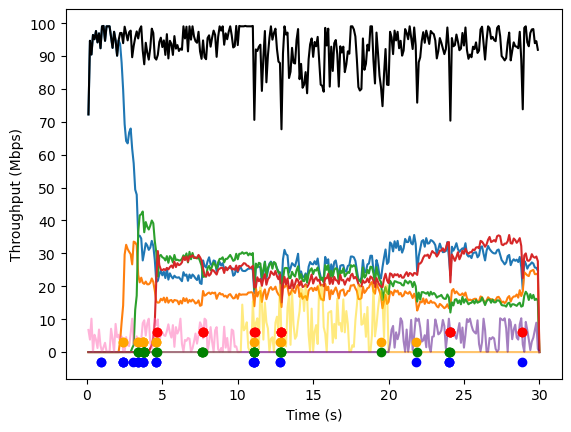

median ratio: 2.091576694786534


([92.7416832,
  94.7629824,
  93.755904,
  93.4797312,
  93.6178176,
  93.4178304,
  94.0606464,
  93.6773376,
  93.3535488,
  93.767808,
  93.6178176],
 [2.5063125810782987,
  2.1705492032696156,
  3.9392440478740447,
  1.5078316042895423,
  2.091576694786534,
  2.121897742691501,
  2.5573101776749407,
  1.8727879998978496,
  1.434314011069036,
  1.4214503895699502,
  2.091576694786534],
 [2.6413502109704643,
  2.3508637236084455,
  28.63450292397661,
  2.378839590443686,
  2.3027969193352247,
  2.1439205955334986,
  2.5787384208204673,
  1.902177793645127,
  1.939966832504146,
  1.43657728231395,
  2.3027969193352247],
 [93.47169684210526,
  93.41827047619047,
  93.333536,
  91.92743619047619,
  94.52393599999999,
  94.73728,
  92.940704,
  93.827552,
  93.08382476190476,
  92.88451555555555,
  94.52393599999999])

In [3]:
iteration = 1
taxConstant = "RawFIFO"
fifo_or_cebinae = "FIFO"
protocol = "Cubic"
raw_fifo = True
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 10):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFOCubic_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
Round: 9
Round: 10
throughput: 93.964224
median fairness: 1.9213144252102237
max fairness: 2.0855842626555994


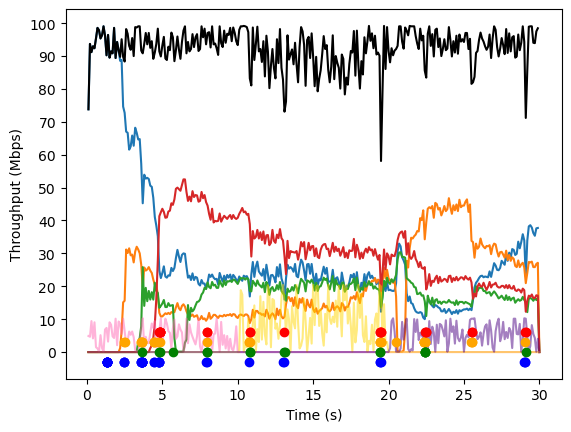

median ratio: 1.9887690419065716


([93.6797184,
  93.1916544,
  93.541632,
  94.0677888,
  93.7939968,
  93.124992,
  93.6106752,
  94.3915776,
  94.6415616,
  95.5986432,
  93.1916544],
 [1.4425049192294266,
  1.9887690419065716,
  2.549470173757354,
  1.4640020089943602,
  3.8457384939251575,
  2.7185607650178696,
  1.298644560045413,
  1.8538598085138756,
  2.471844660194175,
  1.7944271509178122,
  1.9887690419065716],
 [1.5510138397167685,
  2.109522017312759,
  2.668792934249264,
  2.0616465079984394,
  3.8961876832844577,
  2.989283699943599,
  1.5636240244316253,
  1.966460080204156,
  2.5406836783822824,
  1.8296943231441047,
  2.109522017312759],
 [92.20519619047619,
  93.10083047619048,
  92.93288421052631,
  93.934688,
  92.80131368421053,
  92.01815578947368,
  93.70977684210526,
  92.21237894736842,
  93.18019047619048,
  92.63982222222222,
  93.10083047619048])

In [4]:
iteration = 1
taxConstant = "0.001"
fifo_or_cebinae = "FIFO"
protocol = "Cubic"
raw_fifo = False
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 10):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFOCubic_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
Round: 9
Round: 10
throughput: 93.81804288
median fairness: 1.6786526760145604
max fairness: 1.6887646491701094


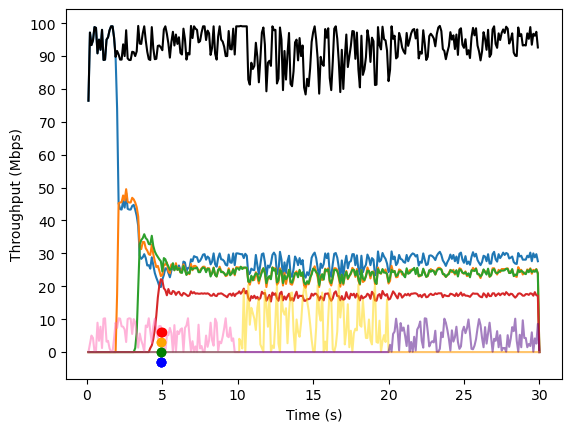

median ratio: 1.6408330488221237


([93.5868672,
  94.7106048,
  94.5487104,
  93.4178304,
  93.2368896,
  93.708288,
  93.7963776,
  93.9154176,
  94.0987392,
  93.160704,
  94.7106048],
 [1.621823032050532,
  1.6408330488221237,
  1.7254351048665009,
  1.6382536622207378,
  1.8896844687044663,
  1.9363416599516519,
  1.5746737917067704,
  1.6001039739836274,
  1.716472303206997,
  1.8952796509321697,
  1.6408330488221237],
 [1.646454924606994,
  1.651052274270197,
  1.7316110513096519,
  1.64860532221866,
  1.9084451460142067,
  1.9463709677419354,
  1.5920162381596752,
  1.6229508196721312,
  1.7264770240700218,
  1.90894757587702,
  1.651052274270197],
 [95.15078736842105,
  94.14766222222222,
  91.51929904761904,
  91.494368,
  91.958624,
  93.488288,
  91.809824,
  94.21726315789473,
  91.48560842105263,
  92.643104,
  94.14766222222222])

In [5]:
iteration = 1
taxConstant = "0.01"
fifo_or_cebinae = "FIFO"
protocol = "Cubic"
raw_fifo = False
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 10):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFOCubic_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
Round: 9
Round: 10
throughput: 94.03231488
median fairness: 1.462488017650056
max fairness: 1.4703247312139471


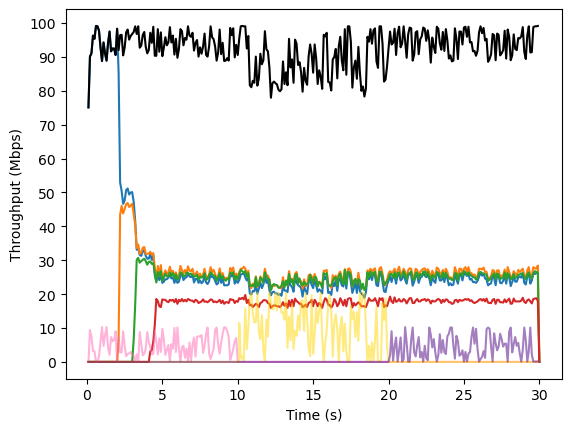

median ratio: 1.4626302551203736


([93.934464,
  93.97255679999999,
  94.005888,
  92.4893184,
  94.5939456,
  94.2534912,
  94.1558784,
  94.7701248,
  93.7535232,
  94.3939584,
  94.5939456],
 [1.4635714899922276,
  1.4620986428334988,
  1.4554521276595747,
  1.459386662519993,
  1.4626302551203736,
  1.4623457801797384,
  1.4678775647494111,
  1.4756272408179187,
  1.4666223845898372,
  1.4504983388704318,
  1.4626302551203736],
 [1.4815425181278838,
  1.4713815789473685,
  1.47130206625123,
  1.4603015075376884,
  1.4693473961766643,
  1.4671750663129972,
  1.4808074123097286,
  1.4804116865869852,
  1.4684594953519254,
  1.4602757715036114,
  1.4693473961766643],
 [92.54723555555556,
  93.73571047619048,
  91.72995368421053,
  92.57365333333334,
  92.851424,
  91.80654222222222,
  94.101344,
  91.40974222222222,
  93.48629333333334,
  93.601376,
  92.851424])

In [6]:
iteration = 1
taxConstant = "0.015"
fifo_or_cebinae = "FIFO"
protocol = "Cubic"
raw_fifo = False
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 10):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFOCubic_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
Round: 9
Round: 10
throughput: 93.93779712
median fairness: 1.6083740879154673
max fairness: 1.619841882089274


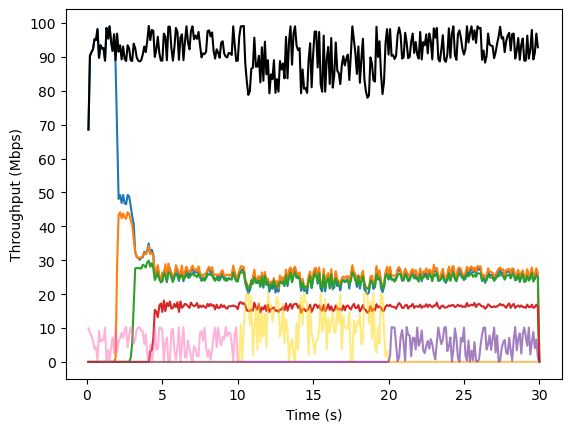

median ratio: 1.6079034104879746


([93.9558912,
  94.5344256,
  92.91072,
  94.6439424,
  94.6225152,
  93.6940032,
  93.5344896,
  93.9011328,
  93.48925440000001,
  94.0915968,
  93.9558912],
 [1.6079034104879746,
  1.60884476534296,
  1.6039336115148388,
  1.6145311381531853,
  1.621951219512195,
  1.5915290739411343,
  1.606872989729167,
  1.6167382306493399,
  1.6158831570489665,
  1.6042568542568543,
  1.6079034104879746],
 [1.6191672648959081,
  1.627865329512894,
  1.605339105339105,
  1.6237942122186493,
  1.633737517831669,
  1.598354792560801,
  1.6205164992826397,
  1.6287553648068667,
  1.6181556195965419,
  1.618774632748119,
  1.6191672648959081],
 [92.46126222222222,
  92.815712,
  92.893088,
  93.5260088888889,
  92.440736,
  91.36344888888888,
  90.173024,
  93.14590315789474,
  91.86606222222223,
  92.79504842105263,
  92.46126222222222])

In [7]:
iteration = 1
taxConstant = "0.017"
fifo_or_cebinae = "FIFO"
protocol = "Cubic"
raw_fifo = False
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 10):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFOCubic_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
Round: 9
Round: 10
throughput: 93.93184512
median fairness: 2.111980929590615
max fairness: 2.138647262145


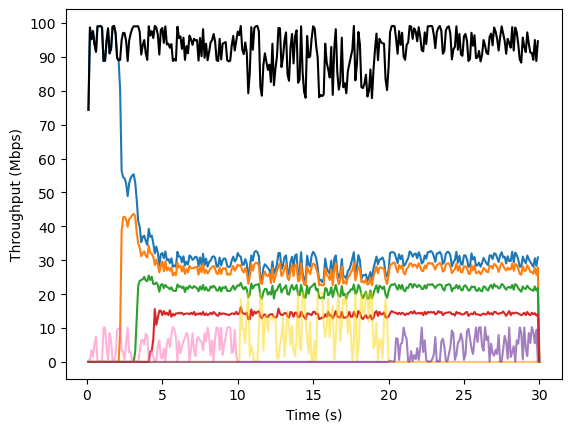

median ratio: 2.110785271389635


([93.339264,
  94.1296896,
  94.2582528,
  93.5106816,
  93.9844608,
  93.648768,
  94.3653888,
  93.8606592,
  93.59400959999999,
  94.6272768,
  93.648768],
 [2.1076890013698817,
  1.8825396825396825,
  2.123436282693378,
  2.1006420378895143,
  2.165774242686398,
  2.110785271389635,
  2.141904972448746,
  1.8811013163651125,
  2.1131765877915956,
  2.134495492204408,
  2.110785271389635],
 [2.131557035803497,
  1.901302803000395,
  2.144573322286661,
  2.1218905472636815,
  2.191646191646192,
  2.1550580431177444,
  2.152191894127378,
  1.8983788058521154,
  2.132721202003339,
  2.1647446457990114,
  2.1550580431177444],
 [93.87893894736843,
  92.10414222222222,
  94.26288761904762,
  93.75838476190476,
  93.6110019047619,
  94.06448761904763,
  91.30389333333333,
  92.89109333333333,
  91.45694476190477,
  93.37292190476191,
  94.06448761904763])

In [8]:
iteration = 1
taxConstant = "0.02"
fifo_or_cebinae = "FIFO"
protocol = "Cubic"
raw_fifo = False
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 10):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFOCubic_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
Round: 9
Round: 10
throughput: 93.94946304
median fairness: 2.3273738057165985
max fairness: 2.343840012108828


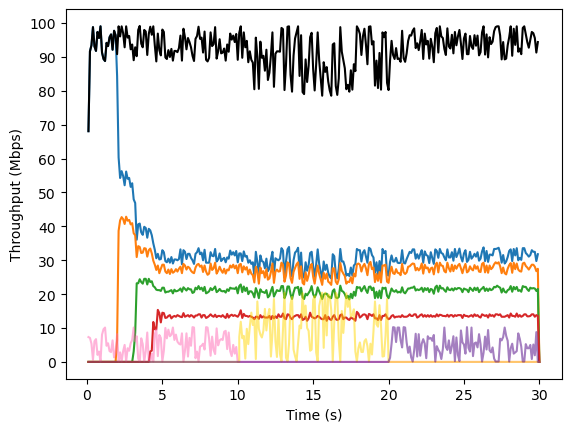

median ratio: 2.3235291102210436


([94.6225152,
  92.9035776,
  94.1392128,
  93.9963648,
  94.446336,
  93.6630528,
  94.0225536,
  93.7606656,
  93.4273536,
  94.5129984,
  94.6225152],
 [2.3235291102210436,
  2.348148173462925,
  2.08469269951442,
  2.0585016835016834,
  2.082217805863207,
  2.3717005625270446,
  2.374460742018982,
  2.3453832752613244,
  2.3110222780139997,
  2.3312185012121533,
  2.3235291102210436],
 [2.3320278503046126,
  2.3613882863340563,
  2.097367321353949,
  2.0943238731218696,
  2.0932274247491636,
  2.3921484037963756,
  2.3801295896328294,
  2.3983634797588285,
  2.324630113141862,
  2.3556521739130436,
  2.3320278503046126],
 [92.87023157894737,
  91.95577904761905,
  90.6492088888889,
  90.655136,
  92.61336888888889,
  93.220448,
  92.09960421052632,
  92.5623161904762,
  93.71604210526316,
  93.53731047619047,
  92.87023157894737])

In [9]:
iteration = 1
taxConstant = "0.022"
fifo_or_cebinae = "FIFO"
protocol = "Cubic"
raw_fifo = False
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 10):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFOCubic_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
Round: 9
Round: 10
throughput: 94.07112192
median fairness: 2.4575791014068393
max fairness: 2.481263565603595


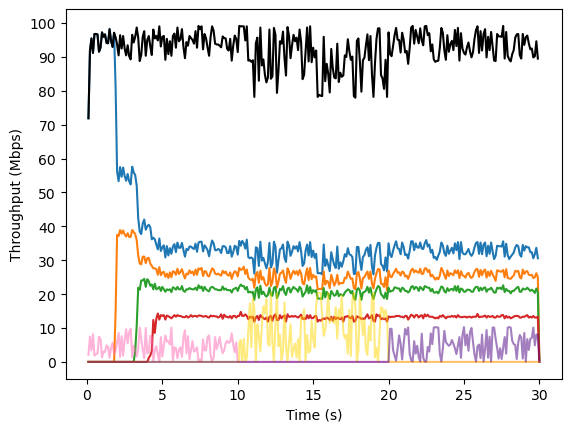

median ratio: 2.4615036535029002


([93.1940352,
  94.2368256,
  94.2153984,
  93.3964032,
  94.9439232,
  93.184512,
  94.7534592,
  94.5272832,
  94.7986944,
  93.4606848,
  93.4606848],
 [2.4117647058823533,
  2.499554764024933,
  2.426506981021654,
  2.4256301937076685,
  2.521700620017715,
  2.405040504050405,
  2.453654549310778,
  2.509325044404973,
  2.497783687943263,
  2.4615036535029002,
  2.4615036535029002],
 [2.4444945848375452,
  2.5155279503105588,
  2.4605026929982046,
  2.457847533632287,
  2.5419240953221536,
  2.4245960502693,
  2.46164139161463,
  2.5296198054818744,
  2.5123893805309736,
  2.50088573959256,
  2.50088573959256],
 [95.119136,
  93.69134222222222,
  91.399136,
  93.85475047619047,
  93.05192421052631,
  92.458592,
  93.09614222222223,
  92.76638476190476,
  92.99553684210527,
  93.6648888888889,
  93.6648888888889])

In [10]:
iteration = 1
taxConstant = "0.023"
fifo_or_cebinae = "FIFO"
protocol = "Cubic"
raw_fifo = False
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 10):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFOCubic_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
Round: 9
Round: 10
throughput: 94.02802944
median fairness: 2.6910354745925216
max fairness: 2.7223937686334896


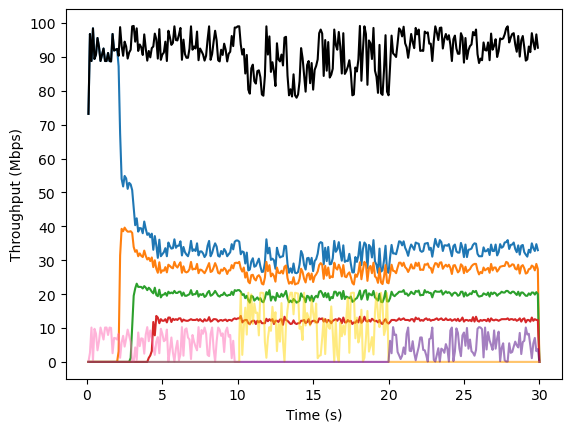

median ratio: 2.6893576222435285


([94.10112,
  93.8225664,
  94.493952,
  94.4653824,
  94.3796736,
  93.5559168,
  94.5320448,
  94.2058752,
  93.553536,
  93.1702272,
  93.5559168],
 [2.6772030651341,
  2.66875,
  2.697604631400042,
  2.724761904761905,
  2.7193903490852964,
  2.6893576222435285,
  2.6982758620689657,
  2.6927133269415147,
  2.6884615384615382,
  2.682606175644721,
  2.6893576222435285],
 [2.7274892806098143,
  2.7189885496183206,
  2.731684110371075,
  2.733238231098431,
  2.731904761904762,
  2.7194656488549622,
  2.714627151051625,
  2.7253218884120174,
  2.706303724928367,
  2.7079349904397705,
  2.7194656488549622],
 [93.33422222222222,
  94.095392,
  92.30915555555556,
  94.41775157894737,
  93.01016888888888,
  90.86940799999999,
  93.6721852631579,
  92.97710222222223,
  93.964448,
  94.2485894736842,
  90.86940799999999])

In [11]:
iteration = 1
taxConstant = "0.025"
fifo_or_cebinae = "FIFO"
protocol = "Cubic"
raw_fifo = False
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 10):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFOCubic_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
Round: 9
Round: 10
throughput: 93.85042176
median fairness: 3.206160975747964
max fairness: 3.2287148897614015


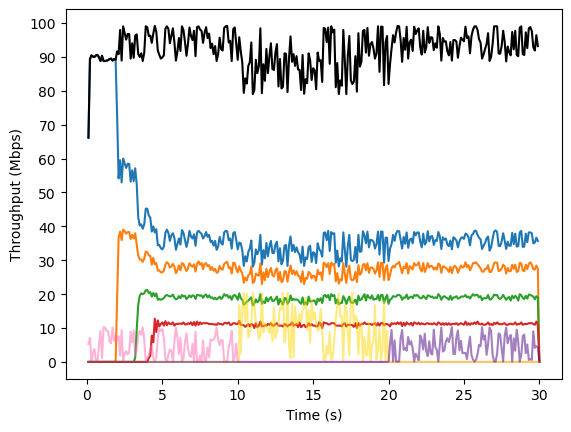

median ratio: 3.2082452431289643


([92.6464512,
  93.8916096,
  94.3439616,
  92.9654784,
  93.9392256,
  93.86304,
  94.0844544,
  94.0487424,
  94.5368064,
  94.184448,
  94.5368064],
 [3.1725053078556265,
  3.2145103082371635,
  3.2182875264270616,
  3.1875,
  3.2032905361165613,
  3.204076708366963,
  3.2162876784769963,
  3.2142099681866383,
  3.2082452431289643,
  3.176069687720335,
  3.2082452431289643],
 [3.2119450317124736,
  3.2444561774023235,
  3.2453825857519787,
  3.219047619047619,
  3.2288583509513744,
  3.223280423280424,
  3.228571428571429,
  3.222457627118644,
  3.239406779661017,
  3.2665615141955837,
  3.239406779661017],
 [88.68501333333333,
  88.32792888888889,
  88.321952,
  88.62864842105263,
  88.43559619047619,
  88.42816,
  88.69041454545454,
  88.411232,
  88.32791578947368,
  88.59431619047619,
  88.32791578947368])

In [12]:
iteration = 1
taxConstant = "0.03"
fifo_or_cebinae = "FIFO"
protocol = "Cubic"
raw_fifo = False
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 10):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFOCubic_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
Round: 9
Round: 10
throughput: 93.70971648
median fairness: 6.2657160311614994
max fairness: 6.366322163065037


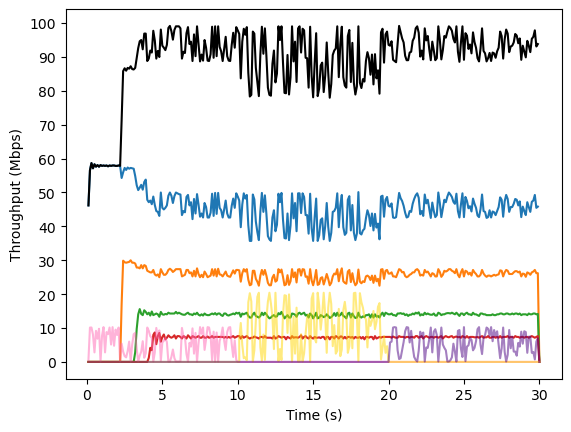

median ratio: 6.26904376012966


([93.92256,
  93.68209920000001,
  94.0130304,
  93.6820992,
  93.0940416,
  94.0320768,
  93.172608,
  93.77495040000001,
  94.1701632,
  93.55353600000001,
  93.172608],
 [6.3334686125967865,
  6.258911497078973,
  6.287852800637808,
  6.315533980582524,
  6.200813008130082,
  6.260129659643436,
  6.26904376012966,
  6.279935275080906,
  6.262388302193338,
  6.254058441558441,
  6.26904376012966],
 [6.3697411003236235,
  6.377022653721682,
  6.392568659127625,
  6.347334410339258,
  6.277957860615883,
  6.380258899676375,
  6.310372771474879,
  6.362903225806452,
  6.408064516129032,
  6.314424635332252,
  6.310372771474879],
 [57.281127619047616,
  57.227149473684214,
  57.28679619047619,
  57.23341473684211,
  57.29813333333333,
  57.220884210526314,
  57.29246476190476,
  57.220884210526314,
  57.17912888888889,
  57.264416,
  57.29246476190476])

In [13]:
iteration = 1
taxConstant = "0.05"
fifo_or_cebinae = "FIFO"
protocol = "Cubic"
raw_fifo = False
show_plot = False

# individual result arrays (experiment-iteration-specific)
results_throughput = []
results_median_fairness = []
results_max_fairness = []
results_median_time = []
results_first2 = []

while (iteration <= 10):
    print("Round: " + str(iteration))
    experimentTitle = fifo_or_cebinae + "_" + taxConstant + "//" + fifo_or_cebinae + protocol + "_" + str(iteration) + "//"
    results_throughput, results_median_fairness, results_max_fairness, results_first2 = plot()
    iteration += 1
        
# individual result arrays (experiment-iteration-specific) are added to all_results arrays (option-wide)
if (not raw_fifo and (taxConstant not in labels)):
    all_throughput_results.append(results_throughput)
    all_median_fairness_results.append(results_median_fairness)
    all_max_fairness_results.append(results_max_fairness)
    all_first2_results.append(results_first2)

    labels.append(taxConstant)
else:
    throughput_median_rawfifo = statistics.median(results_throughput)
#     throughput_median_rawfifo_with_udp = statistics.median(util_with_udp_array)
    fairness_median_rawfifo = statistics.median(results_median_fairness)
    fairness_max_rawfifo = statistics.median(results_max_fairness)

print("throughput: " + str(statistics.mean(results_throughput)))
print("median fairness: " + str(statistics.median(results_median_fairness)))
print("max fairness: " + str(statistics.median(results_max_fairness)))
# print("throughput with udp traffic: " + str(statistics.median(util_with_udp_array)))

# finding value nearest to median fairness value
median_fairness = statistics.median(results_median_fairness)
differences_array = []
for item in results_median_fairness:
    differences_array.append(abs(item - median_fairness))
median_fairness_iteration_to_show = differences_array.index(min(differences_array))

# print(statistics.median(all_median_fairness_results))

# identify the experimentTitle used for plotting; iteration + 1 because folders start at 1 while arrays start at 0
show_plot = True
experimentTitle = "FIFO_" + taxConstant + "//FIFOCubic_" + str(median_fairness_iteration_to_show + 1) + "//"
# showplot()
plot()

In [14]:
iqr_throughput = []
iqr_median_fairness = []
iqr_max_fairness = []
iqr_time = []
iqr_util_first2 = []

q25_throughput = []
q25_median_fairness = []
q25_max_fairness = []
q25_time = []
q25_util_first2 = []

q75_throughput = []
q75_median_fairness = []
q75_max_fairness = []
q75_time = []
q75_util_first2 = []

q50_throughput = []
q50_median_fairness = []
q50_max_fairness = []
q50_time = []
q50_util_first2 = []

throughput_upper_error = []
median_fairness_upper_error = []
max_fairness_upper_error = []
util_first2_upper_error = []

throughput_lower_error = []
median_fairness_lower_error = []
max_fairness_lower_error = []
util_first2_lower_error = []


print(len(labels))

new_labels = []
for index in range(0, len(labels)):
#     new_labels.append(str(int(labels[index]) / 1000000000))
    new_labels.append(labels[index])
    
print(new_labels)
    
df_throughput = pd.DataFrame({label: result for label, result in zip(labels, all_throughput_results)})

df_median_fairness = pd.DataFrame({label: result for label, result in zip(labels, all_median_fairness_results)})

df_max_fairness = pd.DataFrame({label: result for label, result in zip(labels, all_max_fairness_results)})

df_util_first2 = pd.DataFrame({label: result for label, result in zip(labels, all_first2_results)})


#calculate interquartile range of values of throughput, fairness, time and store in iqr array
for value in labels:
    q75, q50, q25 = np.percentile(df_throughput[str(value)], [75,50, 25])
    iqr = q75 - q25
    iqr_throughput.append(iqr)
    q25_throughput.append(q25)
    q50_throughput.append(q50)
    q75_throughput.append(q75)

    q75, q50, q25 = np.percentile(df_median_fairness[value], [75,50, 25])
    iqr = q75 - q25
    iqr_median_fairness.append(iqr)
    q25_median_fairness.append(q25)
    q50_median_fairness.append(q50)
    q75_median_fairness.append(q75)
    
    q75, q50, q25 = np.percentile(df_max_fairness[value], [75,50, 25])
    iqr = q75 - q25
    iqr_max_fairness.append(iqr)
    q25_max_fairness.append(q25)
    q50_max_fairness.append(q50)
    q75_max_fairness.append(q75)
    
    q75, q50, q25 = np.percentile(df_util_first2[value], [75,50, 25])
    iqr = q75 - q25
    iqr_util_first2.append(iqr)
    q25_util_first2.append(q25)
    q50_util_first2.append(q50)
    q75_util_first2.append(q75)
    
for value in labels:
    throughput_upper_error.append(q75_throughput[labels.index(value)] - q50_throughput[labels.index(value)])
    throughput_lower_error.append(q50_throughput[labels.index(value)] - q25_throughput[labels.index(value)])
    
    median_fairness_upper_error.append(q75_median_fairness[labels.index(value)] - q50_median_fairness[labels.index(value)])
    median_fairness_lower_error.append(q50_median_fairness[labels.index(value)] - q25_median_fairness[labels.index(value)])

    max_fairness_upper_error.append(q75_max_fairness[labels.index(value)] - q50_max_fairness[labels.index(value)])
    max_fairness_lower_error.append(q50_max_fairness[labels.index(value)] - q25_max_fairness[labels.index(value)])
    
    util_first2_upper_error.append(q75_util_first2[labels.index(value)] - q50_util_first2[labels.index(value)])
    util_first2_lower_error.append(q50_util_first2[labels.index(value)] - q25_util_first2[labels.index(value)])

10
['0.001', '0.01', '0.015', '0.017', '0.02', '0.022', '0.023', '0.025', '0.03', '0.05']


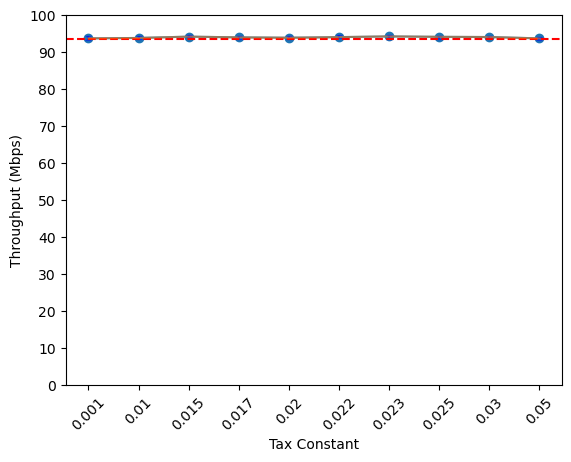

<Figure size 550x200 with 0 Axes>

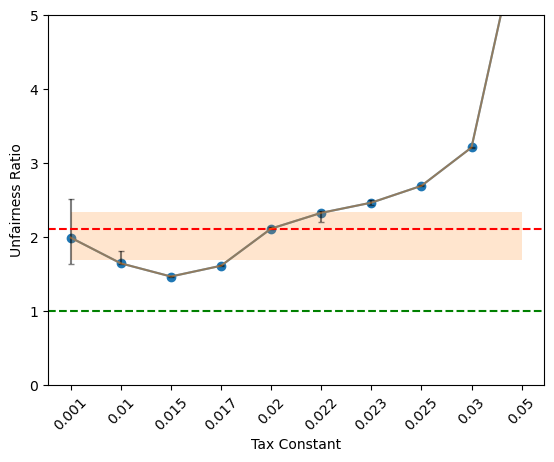

<Figure size 550x200 with 0 Axes>

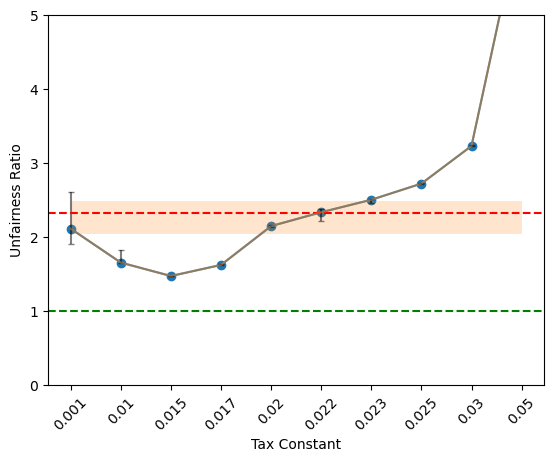

<Figure size 550x200 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [15]:
######################### Tax Constant vs Throughput  ###############
plt.xlabel('Tax Constant')
plt.ylabel('Throughput (Mbps)')
plt.scatter(new_labels, q50_throughput)
# # plt.scatter(new_labels, q50_util_first2)
plt.plot(new_labels, q50_throughput)
# plt.plot(new_labels, q50_util_first2)
plt.errorbar(new_labels, q50_throughput, yerr=[throughput_lower_error, throughput_upper_error], alpha=0.5, ecolor='blue', capsize=2)
# plt.errorbar(new_labels, q50_util_first2, yerr=[util_first2_lower_error, util_first2_upper_error], alpha=0.5, ecolor='black', capsize=2)
plt.axhline(y = throughput_median_rawfifo, color = 'r', linestyle = 'dashed')
yticks = np.arange(0, 110, 10)
plt.yticks(yticks)
plt.xticks(rotation=45, ha="center")
plt.figure(figsize=(5.5, 2))
plt.show()
plt.clf()

######################### Tax Constant vs Median Fairness Ratio ###############
plt.xlabel('Tax Constant')
plt.ylabel('Unfairness Ratio')
plt.scatter(new_labels, q50_median_fairness)
plt.plot(new_labels, q50_median_fairness)
plt.errorbar(new_labels, q50_median_fairness, yerr=[median_fairness_lower_error, median_fairness_upper_error], alpha=0.5, ecolor='black', capsize=2)
plt.axhline(y = fairness_median_rawfifo, color = 'r', linestyle = 'dashed')
plt.axhline(y = 1, color = 'g', linestyle = 'dashed')
plt.fill_between(new_labels, 2.338430892173957, 1.690309802093696, alpha=0.2)
yticks = np.arange(0, 6, 1)
plt.yticks(yticks)
plt.xticks(rotation=45, ha="center")
plt.ylim(0, 5)
plt.figure(figsize=(5.5, 2))
plt.show()
plt.clf()

######################### Tax Constant vs Max Fairness Ratio ###############
plt.xlabel('Tax Constant')
plt.ylabel('Unfairness Ratio')
plt.scatter(new_labels, q50_max_fairness)
plt.plot(new_labels, q50_max_fairness)
plt.errorbar(new_labels, q50_max_fairness, yerr=[max_fairness_lower_error, max_fairness_upper_error], alpha=0.5, ecolor='black', capsize=2)
plt.axhline(y = fairness_max_rawfifo, color = 'r', linestyle = 'dashed')
plt.axhline(y = 1, color = 'g', linestyle = 'dashed')
plt.fill_between(new_labels, 2.478789005632077, 2.041943714018822, alpha=0.2)
yticks = np.arange(0, 7, 1)
plt.yticks(yticks)
plt.xticks(rotation=45, ha="center")
plt.ylim(0, 5)
plt.figure(figsize=(5.5, 2))
plt.show()
plt.clf()

In [16]:
labels = ['123', '456', '789']

for item in labels:
    print(item)

123
456
789
